In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 500

data = {
    "StudyHours": np.random.randint(1, 11, n),
    "Attendance": np.random.randint(50, 101, n),
    "AssignmentScore": np.random.randint(35, 101, n),
    "PreviousExamScore": np.random.randint(30, 101, n),
    "SleepHours": np.round(np.random.uniform(4, 9, n), 1),
    "Participation": np.random.randint(30, 101, n)
}

df = pd.DataFrame(data)

# Create a realistic performance score
score = (
    df["StudyHours"] * 5
    + df["Attendance"] * 0.25
    + df["AssignmentScore"] * 0.20
    + df["PreviousExamScore"] * 0.25
    + df["SleepHours"] * 1.5
    + df["Participation"] * 0.10
    + np.random.normal(0, 8, n)
)

# Pass = 1, Fail = 0
df["Pass"] = (score >= 75).astype(int)

df.head()

,StudyHours,Attendance,AssignmentScore,PreviousExamScore,SleepHours,Participation,Pass
0,7,90,83,97,4.9,50,1
1,4,79,96,49,7.5,59,1
2,8,66,94,97,5.0,42,1
3,5,98,84,93,6.7,63,1
4,7,69,43,46,4.5,33,1


In [5]:
df.shape

(500, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudyHours         500 non-null    int64  
 1   Attendance         500 non-null    int64  
 2   AssignmentScore    500 non-null    int64  
 3   PreviousExamScore  500 non-null    int64  
 4   SleepHours         500 non-null    float64
 5   Participation      500 non-null    int64  
 6   Pass               500 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 27.5 KB


In [7]:
df.describe()

,StudyHours,Attendance,AssignmentScore,PreviousExamScore,SleepHours,Participation,Pass
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,5.430000,74.486000,68.100000,63.798000,6.50700,65.664000,0.812000
std,2.941156,14.946994,18.797252,20.318733,1.45447,19.744944,0.391103
min,1.000000,50.000000,35.000000,30.000000,4.00000,30.000000,0.000000
25%,3.000000,61.750000,51.750000,47.000000,5.20000,49.000000,1.000000
50%,5.000000,74.000000,69.000000,64.000000,6.50000,66.000000,1.000000
75%,8.000000,87.000000,85.000000,79.000000,7.80000,81.000000,1.000000
max,10.000000,100.000000,100.000000,100.000000,9.00000,100.000000,1.000000


In [8]:
df.isnull().sum()

,0
StudyHours,0
Attendance,0
AssignmentScore,0
PreviousExamScore,0
SleepHours,0
Participation,0
Pass,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Pass"].value_counts()

,count
Pass,
1,406
0,94


In [11]:
df["Pass"].value_counts(normalize=True) * 100

,proportion
Pass,
1,81.2
0,18.8


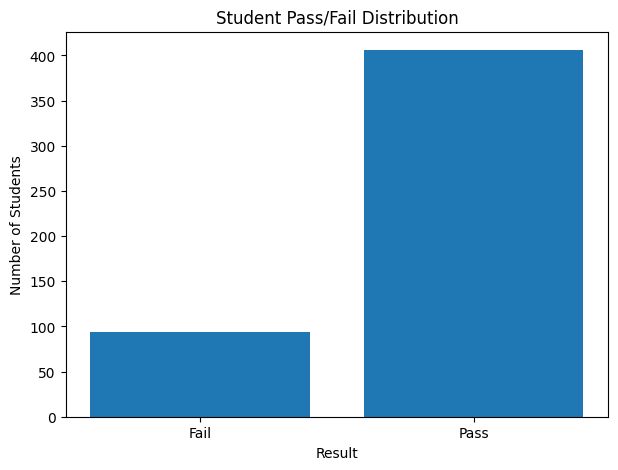

In [12]:
import matplotlib.pyplot as plt

pass_fail_counts = df["Pass"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Fail", "Pass"],
    pass_fail_counts.values
)

plt.title("Student Pass/Fail Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.show()

/tmp/ipykernel_581/3654171947.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


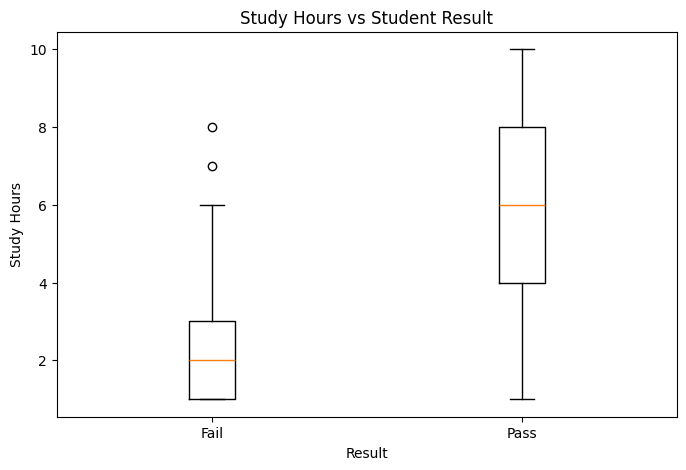

In [13]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df["Pass"] == 0]["StudyHours"],
        df[df["Pass"] == 1]["StudyHours"]
    ],
    labels=["Fail", "Pass"]
)

plt.title("Study Hours vs Student Result")
plt.xlabel("Result")
plt.ylabel("Study Hours")

plt.show()

/tmp/ipykernel_581/3982170714.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


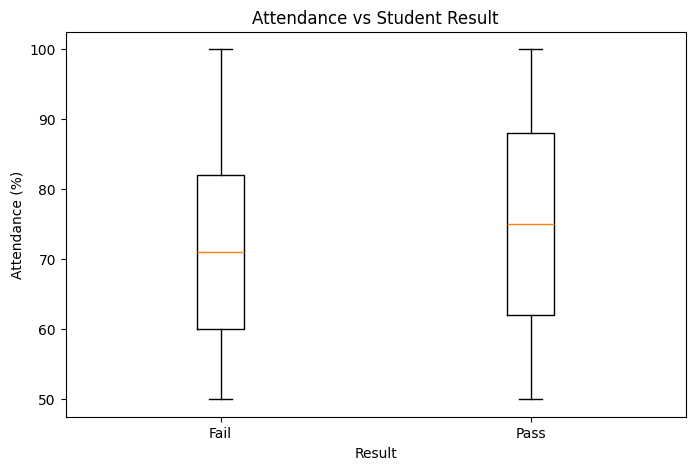

In [14]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df["Pass"] == 0]["Attendance"],
        df[df["Pass"] == 1]["Attendance"]
    ],
    labels=["Fail", "Pass"]
)

plt.title("Attendance vs Student Result")
plt.xlabel("Result")
plt.ylabel("Attendance (%)")

plt.show()

/tmp/ipykernel_581/3224803298.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


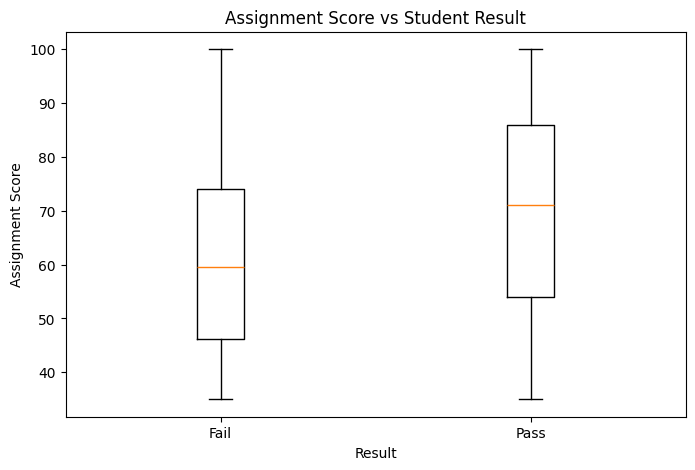

In [15]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df["Pass"] == 0]["AssignmentScore"],
        df[df["Pass"] == 1]["AssignmentScore"]
    ],
    labels=["Fail", "Pass"]
)

plt.title("Assignment Score vs Student Result")
plt.xlabel("Result")
plt.ylabel("Assignment Score")

plt.show()

/tmp/ipykernel_581/4171816059.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


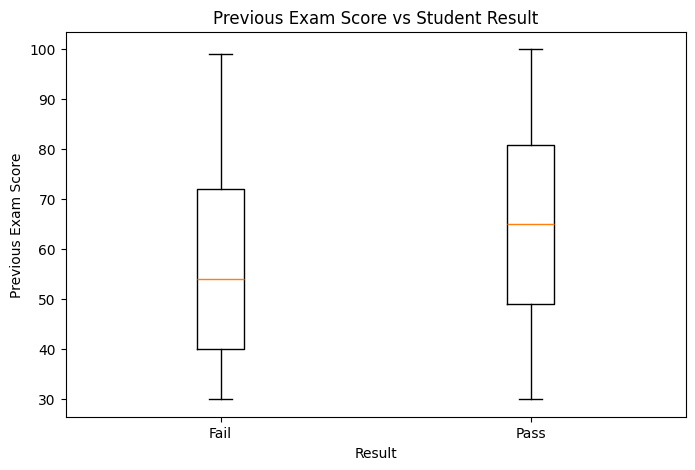

In [16]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df["Pass"] == 0]["PreviousExamScore"],
        df[df["Pass"] == 1]["PreviousExamScore"]
    ],
    labels=["Fail", "Pass"]
)

plt.title("Previous Exam Score vs Student Result")
plt.xlabel("Result")
plt.ylabel("Previous Exam Score")

plt.show()

/tmp/ipykernel_581/3704830254.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


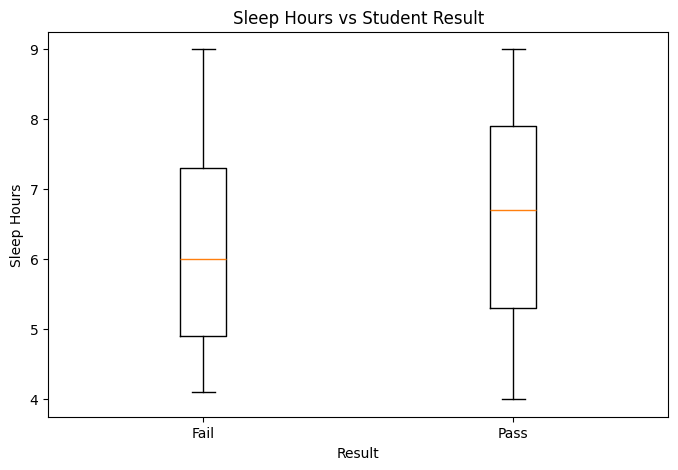

In [17]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df["Pass"] == 0]["SleepHours"],
        df[df["Pass"] == 1]["SleepHours"]
    ],
    labels=["Fail", "Pass"]
)

plt.title("Sleep Hours vs Student Result")
plt.xlabel("Result")
plt.ylabel("Sleep Hours")

plt.show()

/tmp/ipykernel_581/3836207921.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


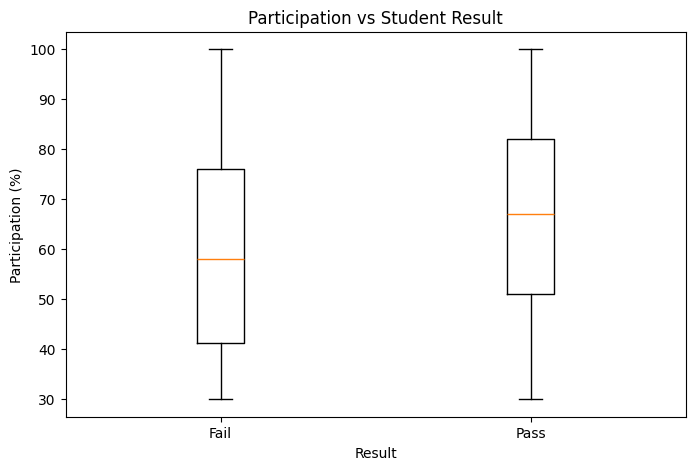

In [18]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df["Pass"] == 0]["Participation"],
        df[df["Pass"] == 1]["Participation"]
    ],
    labels=["Fail", "Pass"]
)

plt.title("Participation vs Student Result")
plt.xlabel("Result")
plt.ylabel("Participation (%)")

plt.show()

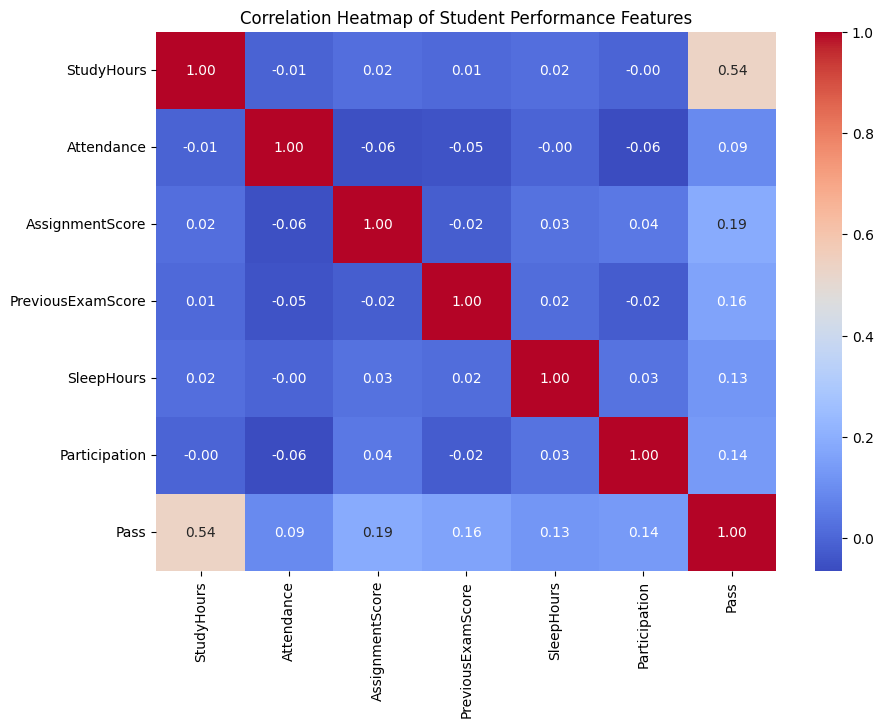

In [19]:
import seaborn as sns

correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Student Performance Features")
plt.show()

In [21]:
x = df[
    [
        "StudyHours",
        "Attendance",
        "AssignmentScore",
        "PreviousExamScore",
        "SleepHours",
        "Participation"
    ]
]

y = df["Pass"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (500, 6)
Target shape: (500,)


In [22]:
x

,StudyHours,Attendance,AssignmentScore,PreviousExamScore,SleepHours,Participation
0,7,90,83,97,4.9,50
1,4,79,96,49,7.5,59
2,8,66,94,97,5.0,42
3,5,98,84,93,6.7,63
4,7,69,43,46,4.5,33
...,...,...,...,...,...,...
495,1,73,97,51,8.4,90
496,7,87,62,73,8.0,45
497,7,84,94,87,6.5,95
498,9,79,71,65,8.8,69


In [23]:
y

,Pass
0,1
1,1
2,1
3,1
4,1
...,...
495,1
496,1
497,1
498,1


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (400, 6)
Testing features: (100, 6)
Training target: (400,)
Testing target: (100,)


In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [26]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:20])

Predictions generated successfully!
[1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1]


In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 94.0 %


In [28]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Fail", "Pass"]
))

              precision    recall  f1-score   support

        Fail       0.84      0.84      0.84        19
        Pass       0.96      0.96      0.96        81

    accuracy                           0.94       100
   macro avg       0.90      0.90      0.90       100
weighted avg       0.94      0.94      0.94       100



In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[16  3]
 [ 3 78]]


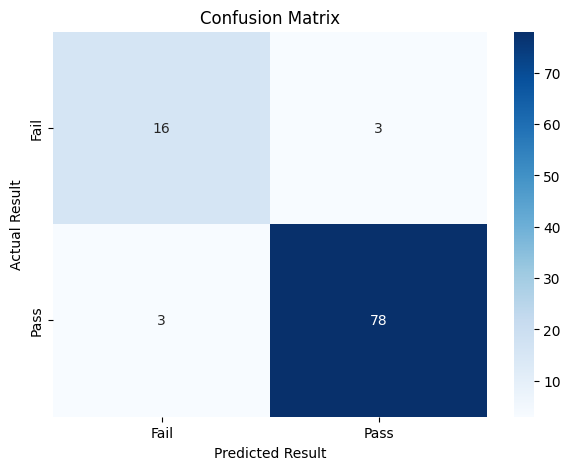

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Result")
plt.ylabel("Actual Result")

plt.show()

In [31]:
new_student = pd.DataFrame({
    "StudyHours": [7],
    "Attendance": [88],
    "AssignmentScore": [82],
    "PreviousExamScore": [78],
    "SleepHours": [7],
    "Participation": [80]
})

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Prediction: PASS")
else:
    print("Prediction: FAIL")

Prediction: PASS


In [32]:
probability = model.predict_proba(new_student)

print("Fail Probability:", round(probability[0][0] * 100, 2), "%")
print("Pass Probability:", round(probability[0][1] * 100, 2), "%")

Fail Probability: 0.06 %
Pass Probability: 99.94 %


In [33]:
feature_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_coefficients = feature_coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

feature_coefficients

,Feature,Coefficient
0,StudyHours,1.045348
4,SleepHours,0.327602
2,AssignmentScore,0.045336
3,PreviousExamScore,0.042884
1,Attendance,0.037717
5,Participation,0.025462


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaled_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(max_iter=1000))
])

scaled_model.fit(X_train, y_train)

print("Scaled model training completed successfully!")

Scaled model training completed successfully!


In [35]:
y_pred_scaled = scaled_model.predict(X_test)

scaled_accuracy = accuracy_score(y_test, y_pred_scaled)

print("Original Model Accuracy:", round(accuracy * 100, 2), "%")
print("Scaled Model Accuracy:", round(scaled_accuracy * 100, 2), "%")

Original Model Accuracy: 94.0 %
Scaled Model Accuracy: 94.0 %


In [36]:
print(classification_report(
    y_test,
    y_pred_scaled,
    target_names=["Fail", "Pass"]
))

              precision    recall  f1-score   support

        Fail       0.84      0.84      0.84        19
        Pass       0.96      0.96      0.96        81

    accuracy                           0.94       100
   macro avg       0.90      0.90      0.90       100
weighted avg       0.94      0.94      0.94       100



In [37]:
from sklearn.metrics import confusion_matrix

cm_scaled = confusion_matrix(y_test, y_pred_scaled)

print(cm_scaled)

[[16  3]
 [ 3 78]]


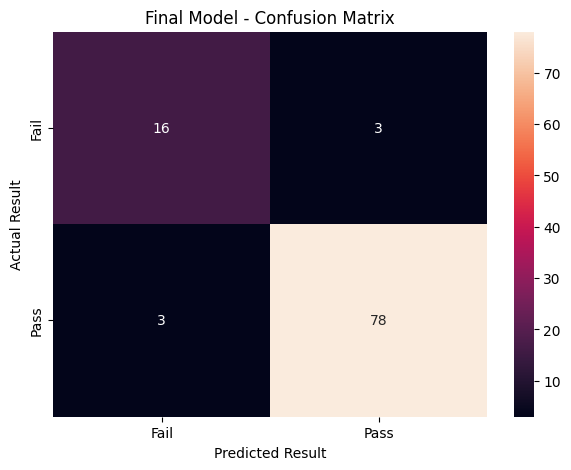

In [38]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_scaled,
    annot=True,
    fmt="d",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.title("Final Model - Confusion Matrix")
plt.xlabel("Predicted Result")
plt.ylabel("Actual Result")

plt.show()

In [40]:
def predict_student_performance(
    study_hours,
    attendance,
    assignment_score,
    previous_exam_score,
    sleep_hours,
    participation
):
    student = pd.DataFrame({
        "StudyHours": [study_hours],
        "Attendance": [attendance],
        "AssignmentScore": [assignment_score],
        "PreviousExamScore": [previous_exam_score],
        "SleepHours": [sleep_hours],
        "Participation": [participation]
    })

    prediction = scaled_model.predict(student)
    probability = scaled_model.predict_proba(student)[0]

    result = "PASS" if prediction[0] == 1 else "FAIL"

    print("Predicted Result:", result)
    print("Fail Probability:", round(probability[0] * 100, 2), "%")
    print("Pass Probability:", round(probability[1] * 100, 2), "%")

In [42]:
predict_student_performance(
    study_hours=7,
    attendance=88,
    assignment_score=82,
    previous_exam_score=78,
    sleep_hours=7,
    participation=80
)

Predicted Result: PASS
Fail Probability: 0.12 %
Pass Probability: 99.88 %


In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": scaled_model,
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier())
    ])
}

model_results = {}

for name, current_model in models.items():
    current_model.fit(X_train, y_train)
    predictions = current_model.predict(X_test)
    model_results[name] = accuracy_score(y_test, predictions)

for name, score in model_results.items():
    print(f"{name}: {score * 100:.2f}%")

Logistic Regression: 94.00%
Decision Tree: 87.00%
Random Forest: 90.00%
K-Nearest Neighbors: 83.00%


In [44]:
model_comparison = pd.DataFrame({
    "Model": model_results.keys(),
    "Accuracy": model_results.values()
})

model_comparison["Accuracy (%)"] = (
    model_comparison["Accuracy"] * 100
).round(2)

model_comparison

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.94,94.0
1,Decision Tree,0.87,87.0
2,Random Forest,0.90,90.0
3,K-Nearest Neighbors,0.83,83.0


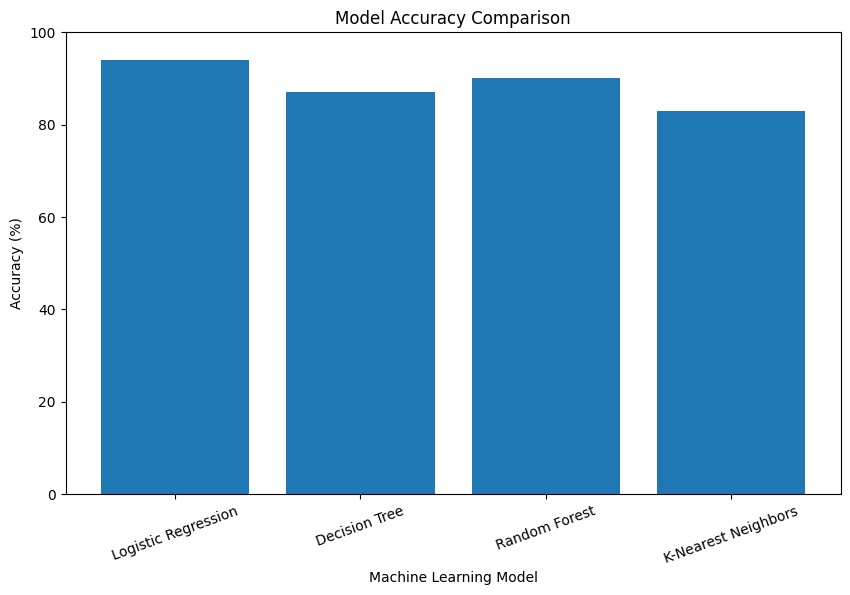

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy (%)"]
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)

plt.xticks(rotation=20)
plt.show()

In [46]:
best_model_name = model_comparison.loc[
    model_comparison["Accuracy"].idxmax(),
    "Model"
]

best_accuracy = model_comparison.loc[
    model_comparison["Accuracy"].idxmax(),
    "Accuracy (%)"
]

print("Selected Model:", best_model_name)
print("Test Accuracy:", best_accuracy, "%")

Selected Model: Logistic Regression
Test Accuracy: 94.0 %


In [47]:
final_model = models[best_model_name]

final_predictions = final_model.predict(X_test)

print("Final Model:", best_model_name)
print()

print(classification_report(
    y_test,
    final_predictions,
    target_names=["Fail", "Pass"]
))

Final Model: Logistic Regression

              precision    recall  f1-score   support

        Fail       0.84      0.84      0.84        19
        Pass       0.96      0.96      0.96        81

    accuracy                           0.94       100
   macro avg       0.90      0.90      0.90       100
weighted avg       0.94      0.94      0.94       100



In [48]:
from sklearn.metrics import confusion_matrix

final_cm = confusion_matrix(y_test, final_predictions)

print("Confusion Matrix:")
print(final_cm)

Confusion Matrix:
[[16  3]
 [ 3 78]]


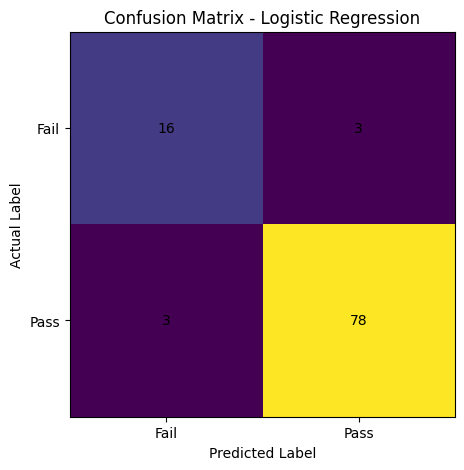

In [49]:
plt.figure(figsize=(6, 5))

plt.imshow(final_cm)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Fail", "Pass"])
plt.yticks([0, 1], ["Fail", "Pass"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, final_cm[i, j],
                 ha="center",
                 va="center")

plt.show()

In [50]:
new_student = pd.DataFrame({
    "StudyHours": [8],
    "Attendance": [92],
    "AssignmentScore": [88],
    "PreviousExamScore": [85],
    "SleepHours": [7],
    "Participation": [90]
})

new_student

,StudyHours,Attendance,AssignmentScore,PreviousExamScore,SleepHours,Participation
0,8,92,88,85,7,90


In [51]:
prediction = final_model.predict(new_student)
probability = final_model.predict_proba(new_student)[0]

result = "PASS" if prediction[0] == 1 else "FAIL"

print("===== Student Performance Prediction =====")
print("Predicted Result:", result)
print("Fail Probability:", round(probability[0] * 100, 2), "%")
print("Pass Probability:", round(probability[1] * 100, 2), "%")

===== Student Performance Prediction =====
Predicted Result: PASS
Fail Probability: 0.02 %
Pass Probability: 99.98 %


In [52]:
import joblib

joblib.dump(final_model, "student_performance_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [53]:
df.to_csv("student_performance_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [54]:
study_hours = float(input("Enter Study Hours: "))
attendance = float(input("Enter Attendance (%): "))
assignment_score = float(input("Enter Assignment Score: "))
previous_exam_score = float(input("Enter Previous Exam Score: "))
sleep_hours = float(input("Enter Sleep Hours: "))
participation = float(input("Enter Participation Score: "))

student = pd.DataFrame({
    "StudyHours": [study_hours],
    "Attendance": [attendance],
    "AssignmentScore": [assignment_score],
    "PreviousExamScore": [previous_exam_score],
    "SleepHours": [sleep_hours],
    "Participation": [participation]
})

prediction = final_model.predict(student)
probability = final_model.predict_proba(student)[0]

result = "PASS" if prediction[0] == 1 else "FAIL"

print("\n===== Student Performance Prediction =====")
print("Predicted Result:", result)
print("Fail Probability:", round(probability[0] * 100, 2), "%")
print("Pass Probability:", round(probability[1] * 100, 2), "%")

Enter Study Hours: 8
Enter Attendance (%): 92
Enter Assignment Score: 88
Enter Previous Exam Score: 85
Enter Sleep Hours: 7
Enter Participation Score: 90

===== Student Performance Prediction =====
Predicted Result: PASS
Fail Probability: 0.02 %
Pass Probability: 99.98 %


In [55]:
readme_content = """
# Student Performance Prediction Using Machine Learning

## Project Overview

This project predicts whether a student is likely to Pass or Fail based on academic and behavioral factors.

## Features Used

- Study Hours
- Attendance
- Assignment Score
- Previous Exam Score
- Sleep Hours
- Participation

## Machine Learning Models

The project compares multiple classification algorithms:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)

## Workflow

1. Dataset Generation
2. Data Understanding
3. Data Cleaning
4. Exploratory Data Analysis
5. Data Visualization
6. Feature Selection
7. Train-Test Split
8. Model Training
9. Model Comparison
10. Model Evaluation
11. Student Prediction
12. Model Saving

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Joblib
- Google Colab

## Dataset

The dataset used in this project is synthetically generated for educational and demonstration purposes.

It contains 500 student records and 6 input features.

## Model Evaluation

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

## Prediction System

The system accepts student information as input and predicts:

- PASS or FAIL
- Pass Probability
- Fail Probability

## Important Limitation

This project uses a synthetic dataset and is intended for educational purposes. The model should not be treated as a real-world student assessment system without validation on genuine student data.

## Author

Harshit Kumar Singh
"""

with open("README.md", "w") as file:
    file.write(readme_content)

print("README.md created successfully!")

README.md created successfully!


In [56]:
requirements = """
pandas
numpy
matplotlib
seaborn
scikit-learn
joblib
"""

with open("requirements.txt", "w") as file:
    file.write(requirements.strip())

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [57]:
import os

print(os.listdir())

['.config', 'student_performance_dataset.csv', 'README.md', 'student_performance_model.pkl', 'requirements.txt', 'sample_data']
